In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


In [2]:
full_base_data = pd.read_csv('./data/vattuniemi.csv')
cleaned_base = full_base_data.drop([1, 13])
#display(cleaned_base)

In [3]:
def avg_error(model, x, y):
  preds = model.predict(x)
  residuals = abs(y - preds)
  return np.mean(residuals)


offices = cleaned_base.loc[cleaned_base["Type"] == "office"]

X = offices[["Area", "Volume", "Storeys"]]
y_con = offices[["Concrete"]]
y_min = offices[["Mineral_wool"]]
y_met = offices[["Metal"]]
y_gla = offices[["Glass"]]

con_model = LinearRegression().fit(X, y_con)
con_coef = con_model.coef_
con_intercept = con_model.intercept_
con_error = avg_error(con_model, X, y_con)

min_model = LinearRegression().fit(X, y_min)
min_coef = min_model.coef_
min_intercept = min_model.intercept_
min_error = avg_error(min_model, X, y_min)

met_model = LinearRegression().fit(X, y_met)
met_coef = met_model.coef_
met_intercept = met_model.intercept_
met_error = avg_error(met_model, X, y_met)

gla_model = LinearRegression().fit(X, y_gla)
gla_coef = gla_model.coef_
gla_intercept = gla_model.intercept_
gla_error = avg_error(gla_model, X, y_gla)


/home/joel/Code/work/dippa/msc-thesis/code/env/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3472: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/home/joel/Code/work/dippa/msc-thesis/code/env/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3472: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/home/joel/Code/work/dippa/msc-thesis/code/env/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3472: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.

In [4]:
generated_data = pd.DataFrame(np.zeros(shape=(100,7)), columns=["Area", "Volume", "Storeys", "Concrete", "Mineral_wool", "Metal", "Glass"])
storeys = [2, 3, 4, 5, 6]

nr_storeys = np.random.choice(storeys, size=100)

area_mus = nr_storeys * 3000
volume_mus = area_mus * 3.5

area_sigmas = np.random.normal(1000, 50, 100)
volume_sigmas = np.random.normal(1000, 50, 100)

for i in range(100):
  area = np.random.normal(area_mus[i], area_sigmas[i], 1)
  volume = np.random.normal(volume_mus[i], volume_sigmas[i], 1)
  storeys = nr_storeys[i]
  input = np.array([area, volume, storeys]).reshape(1, -1)
  concrete = con_model.predict(input) + np.random.normal(0, con_error, 1)
  mineral_wool = min_model.predict(input) + np.random.normal(0, min_error, 1)
  metal = met_model.predict(input) + np.random.normal(0, met_error, 1)
  glass = gla_model.predict(input) + np.random.normal(0, gla_error, 1)
  generated_data.loc[i] = area, volume, storeys, concrete, mineral_wool, metal, glass

generated_data.to_csv("./data/generated_data.csv")
areas = generated_data["Area"]


/tmp/ipykernel_10289/1052390134.py:16: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  input = np.array([area, volume, storeys]).reshape(1, -1)
/home/joel/Code/work/dippa/msc-thesis/code/env/lib/python3.8/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/joel/Code/work/dippa/msc-thesis/code/env/lib/python3.8/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/joel/Code/work/dippa/msc-thesis/code/env/lib/python3.8/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.

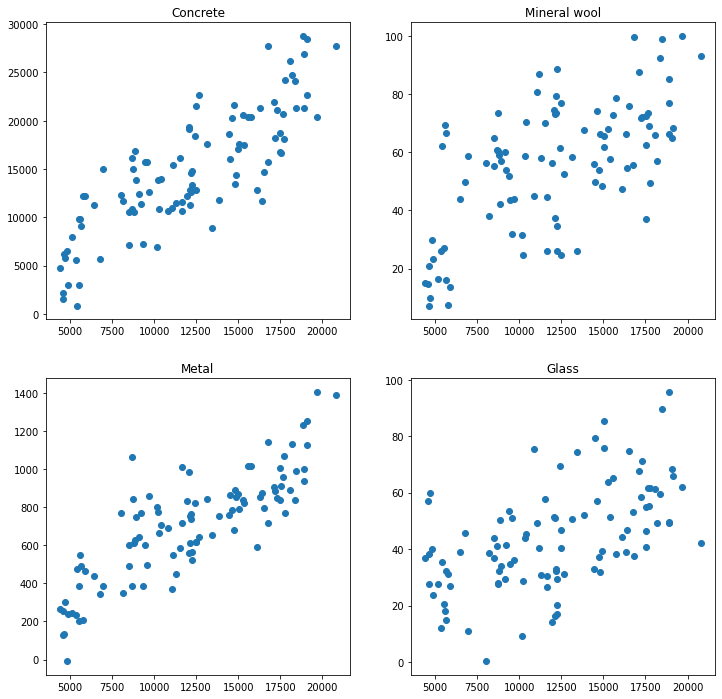

In [5]:
fig = plt.figure(figsize=(12, 12))

ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

ax1.set_title("Concrete")
ax1.plot(areas, generated_data["Concrete"], 'o')
#ax1.plot(x, con_coef*x + con_intercept)

ax2.set_title("Mineral wool")
ax2.plot(areas, generated_data["Mineral_wool"], 'o')
#ax2.plot(x, min_coef*x + min_intercept)

ax3.set_title("Metal")
ax3.plot(areas, generated_data["Metal"], 'o')
#ax3.plot(x, met_coef*x + met_intercept)

ax4.set_title("Glass")
ax4.plot(areas, generated_data["Glass"], 'o')
#ax4.plot(x, gla_coef*x + gla_intercept)

plt.show()
